<a href="https://colab.research.google.com/github/KiiJull/TUGAS-PERTEMUAN-6-PENGOLAHAN-CITRA/blob/main/Pengolahan_citra_pertemuan_6_m_rizky_putra_julianudin_237006516048.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Tugas Pertemuan 6 – Laporan Pengolahan Citra dengan Python
🔗 Akses Notebook di Google Colab:
👉 Buka di Google Colab

Nama: M. RIZKY PUTRA JULIANUDIN

NPM: 237006526048

Program Studi: Sistem Informasi


Mata Kuliah: Pengolahan Citra

Kelas: R.01

Bahasa Pemrograman: Python (OpenCV, NumPy, scikit-image, matplotlib, pandas)

📦 Persiapan Lingkungan
Pastikan paket berikut sudah terpasang sebelum menjalankan kode:# Bagian Baru

In [ ]:
!pip install opencv-python matplotlib numpy scikit-image
!pip install ipython
import pandas as pd
from IPython import display
from google.colab import files
import cv2, numpy as np
import matplotlib.pyplot as plt
from skimage import exposure, data, img_as_ubyte, img_as_float, io
from skimage.measure import shannon_entropy
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
from math import log10

# LATIHAN 1: Penghalusan Citra dengan Filter Gaussian (Spasial vs. Frekuensi)

**Tujuan:** Mempelajari efek blur menggunakan filter Gaussian di domain spasial dan frekuensi.

**Hasil Utama:** Filter Gaussian mengurangi detail dan noise. Metrik SSIM menunjukkan struktur gambar asli masih terjaga meskipun ada perubahan piksel yang signifikan.

**Kesimpulan:** Gaussian filter efektif untuk penghalusan, menghasilkan blur yang natural tanpa artifak.

MSE: 157.5101432800293
PSNR: 26.157718343060953
SSIM: 0.7389728278597633


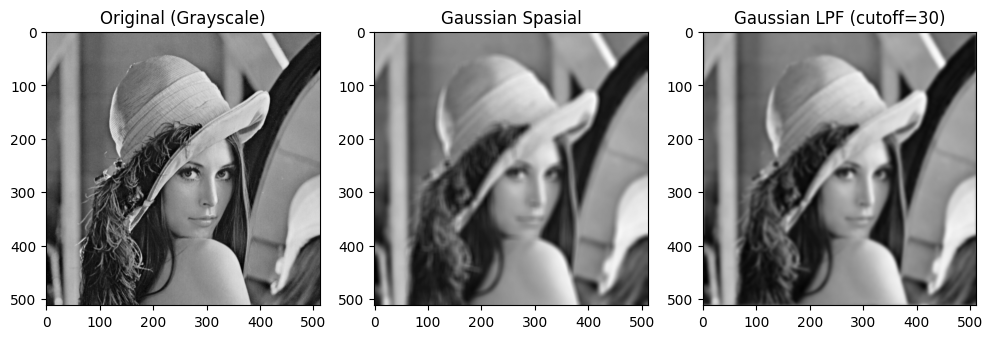

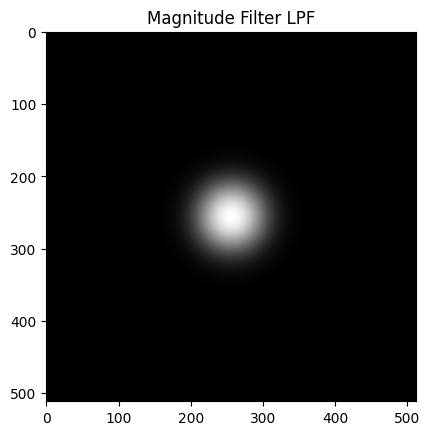

In [ ]:
import cv2
import numpy as np
from math import log10
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from google.colab import files

# LATIHAN 1

# --- Load Image ---
# Gunakan baris ini untuk mengupload jika Anda berada di Google Colab
# uploaded = files.upload()

# NAMA FILE GAMBAR DIGANTI MENJADI "lenna.png" (sesuaikan ekstensi jika berbeda, misal "lenna.jpg")
img_path = "lenna.png"
# Untuk memastikan gambar sudah diupload ke lingkungan Colab Anda,
# Anda mungkin perlu menjalankan files.upload() secara manual atau memastikan file tersebut sudah ada.
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) # Akan dibaca sebagai grayscale

if img is None:
    print(f"Error: Could not load image from {img_path}. Please check if the file exists, is a valid image format, and has been uploaded.")
    raise FileNotFoundError(f"Image {img_path} not found or could not be read by OpenCV.")


# ------------------------------
# Fungsi MSE, PSNR
# ------------------------------
def MSE(a, b):
    return np.mean((a.astype("float") - b.astype("float")) ** 2)

def PSNR(a, b):
    mse = MSE(a, b)
    if mse == 0: return 100
    return 20 * log10(255 / np.sqrt(mse))

# ------------------------------
# 1) Gaussian Blur Spasial
# ------------------------------
blur_spatial = cv2.GaussianBlur(img, (11, 11), sigmaX=10)

# ------------------------------
# 2) Gaussian LPF di Frekuensi
# ------------------------------
def gaussian_lpf_freq(image, cutoff):
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    M, N = image.shape
    X, Y = np.meshgrid(np.arange(N), np.arange(M))
    cx, cy = N//2, M//2
    D = np.sqrt((X-cx)**2 + (Y-cy)**2)
    H = np.exp(-(D**2) / (2*(cutoff**2)))
    filtered = fshift * H
    unshift = np.fft.ifftshift(filtered)
    out = np.abs(np.fft.ifft2(unshift))
    return out, H

img30, H30 = gaussian_lpf_freq(img, 30)

# ------------------------------
# 3) Metrics
# ------------------------------
print("MSE:", MSE(img, blur_spatial))
print("PSNR:", PSNR(img, blur_spatial))
print("SSIM:", ssim(img, blur_spatial))

# ------------------------------
# 4) Plot
# ------------------------------
plt.figure(figsize=(12,6))
plt.subplot(1,3,1); plt.imshow(img, cmap='gray'); plt.title("Original (Grayscale)")
plt.subplot(1,3,2); plt.imshow(blur_spatial, cmap='gray'); plt.title("Gaussian Spasial")
plt.subplot(1,3,3); plt.imshow(img30, cmap='gray'); plt.title("Gaussian LPF (cutoff=30)")
plt.show()

plt.figure(); plt.imshow(np.log(1+np.abs(H30)), cmap='gray'); plt.title("Magnitude Filter LPF")
plt.show()

# Analisis Singkat LATIHAN 2 (Sharpening Citra)

**Tujuan**: Membandingkan dua metode penajaman citra: Laplacian Sharpening (domain spasial) dan Gaussian High-Pass Filter (HPF) (domain frekuensi).

**Hasil** **Utama**: Dari metrik PSNR dan SSIM, Laplacian Sharpening menunjukkan kinerja yang jauh lebih baik (PSNR sekitar 28.38, SSIM sekitar 0.907). Ini berarti metode ini berhasil menajamkan gambar sambil mempertahankan kualitas dan struktur visual yang tinggi.

**Kesimpulan**: Gaussian HPF dengan parameter yang digunakan menghasilkan kualitas citra yang sangat buruk (PSNR sekitar 8.92, SSIM sekitar 0.059), menunjukkan bahwa metode ini menyebabkan degradasi yang signifikan. Hal ini menunjukkan pentingnya pemilihan filter dan parameter yang tepat untuk setiap teknik penajaman.

--- Hasil Metrik ---
PSNR Laplacian: 28.3790
SSIM Laplacian: 0.9070
PSNR HPF: 8.9217
SSIM HPF: 0.0592

--- Tabel Perbandingan Metrik ---
                     Metode       PSNR      SSIM
0      Laplacian Sharpening  28.378997  0.906973
1  Gaussian HPF (Frekuensi)   8.921675  0.059186


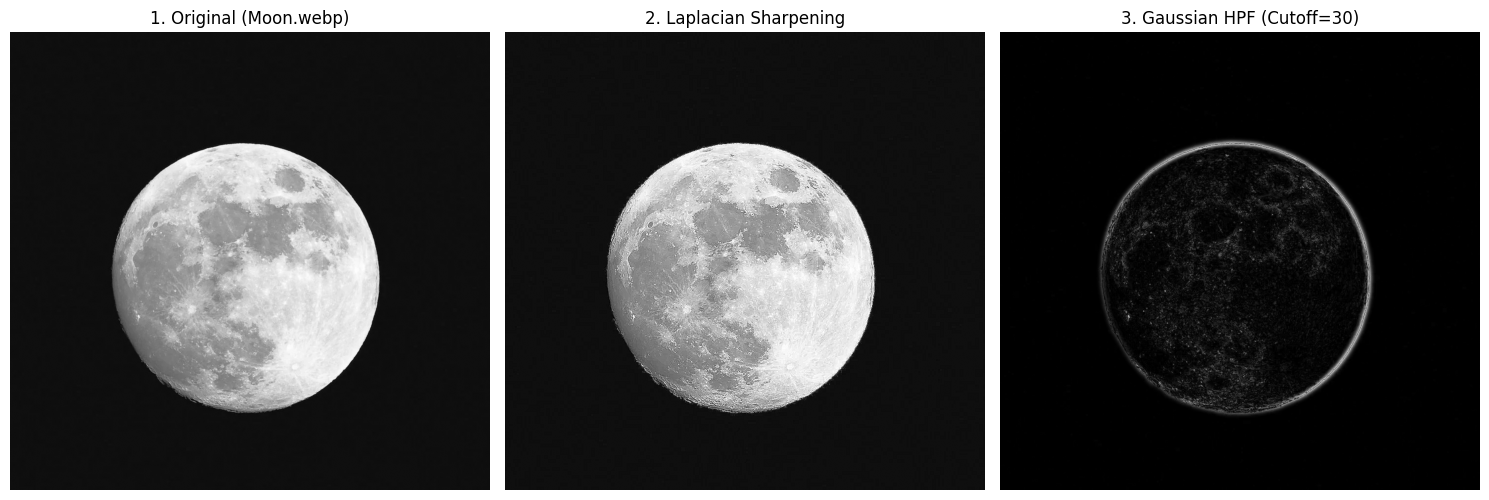

In [ ]:
import cv2
import numpy as np
import pandas as pd
from math import log10
import matplotlib.pyplot as plt # <--- HARUS DIIMPORT
from skimage.metrics import structural_similarity as ssim

# --- FUNGSI PSNR ---
def MSE(a, b):
    return np.mean((a.astype("float") - b.astype("float")) ** 2)

def PSNR(a, b):
    mse = MSE(a, b)
    if mse == 0: return 100
    return 20 * log10(255 / np.sqrt(mse))

# LATIHAN 2

# Load Moon
img_path = "Moon.webp" # Menggunakan file terbaru
moon = cv2.imread(img_path, 0) # Membaca sebagai grayscale

if moon is None:
    print(f"Error: Could not load image from {img_path}. Please check if the file exists, is a valid image format, and has been uploaded.")
    raise FileNotFoundError(f"Image {img_path} not found or could not be read by OpenCV.")

# 1) Laplacian Sharpening
lap = cv2.Laplacian(moon, cv2.CV_64F)
sharp_lap = cv2.convertScaleAbs(moon - lap)

# 2) Gaussian HPF Frekuensi
img_f = np.fft.fftshift(np.fft.fft2(moon))
M, N = moon.shape
X, Y = np.meshgrid(np.arange(N), np.arange(M))
cx, cy = N//2, M//2
D = np.sqrt((X-cx)**2 + (Y-cy)**2)
cutoff = 30
Hhp = 1 - np.exp(-(D**2)/(2*(cutoff**2)))
filtered = img_f * Hhp
sharp_freq = np.abs(np.fft.ifft2(np.fft.ifftshift(filtered)))

# Convert sharp_freq (float) to uint8
sharp_freq_uint8 = (255 * (sharp_freq - sharp_freq.min()) / (sharp_freq.max() - sharp_freq.min())).astype(np.uint8)


# --- HITUNG METRIK ---
psnr_lap = PSNR(moon, sharp_lap)
ssim_lap = ssim(moon, sharp_lap)

psnr_hpf = PSNR(moon, sharp_freq_uint8)
ssim_hpf = ssim(moon, sharp_freq_uint8)

print("--- Hasil Metrik ---")
print(f"PSNR Laplacian: {psnr_lap:.4f}")
print(f"SSIM Laplacian: {ssim_lap:.4f}")
print(f"PSNR HPF: {psnr_hpf:.4f}")
print(f"SSIM HPF: {ssim_hpf:.4f}")

# Buat tabel menggunakan Pandas DataFrame
df = pd.DataFrame({
    "Metode": ["Laplacian Sharpening", "Gaussian HPF (Frekuensi)"],
    "PSNR": [psnr_lap, psnr_hpf],
    "SSIM": [ssim_lap, ssim_hpf]
})

print("\n--- Tabel Perbandingan Metrik ---")
print(df)


# ----------------------------------
# 3) Plot Visualisasi (KODE BARU DITAMBAHKAN)
# ----------------------------------
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(moon, cmap='gray')
plt.title(f"1. Original ({img_path})")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sharp_lap, cmap='gray')
plt.title("2. Laplacian Sharpening")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(sharp_freq_uint8, cmap='gray')
plt.title(f"3. Gaussian HPF (Cutoff={cutoff})")
plt.axis('off')

plt.tight_layout()
plt.show() # <--- PERINTAH UNTUK MENAMPILKAN GAMBAR

# **Analisis Singkat LATIHAN 3 (Filter Low-Pass Ideal vs. Gaussian)**

**Tujuan:** Membandingkan efek filter Low-Pass Ideal dan Gaussian Low-Pass Filter (LPF) di domain frekuensi untuk penghalusan citra.

**Hasil Utama:** Secara visual, Ideal LPF cenderung menghasilkan ringing artifacts (efek gelombang) di sekitar tepi objek karena transisi cutoff-nya yang sangat tajam di domain frekuensi. Sebaliknya, Gaussian LPF menghasilkan penghalusan yang lebih halus dan lebih alami tanpa ringing yang terlihat, berkat transisi frekuensinya yang lebih mulus.

**Kesimpulan:** Meskipun keduanya adalah filter low-pass yang menyebabkan blurring, Gaussian LPF umumnya lebih disukai karena menghasilkan efek penghalusan yang lebih mulus dan tidak menimbulkan artifak yang mengganggu dibandingkan Ideal LPF.

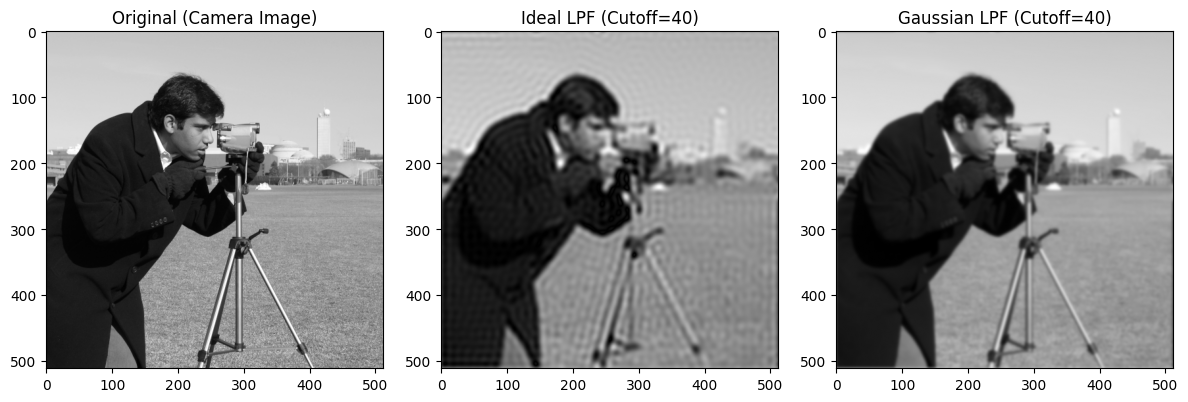

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

# --- FUNGSI Gaussian LPF (Diambil dari LATIHAN 1) ---
def gaussian_lpf_freq(image, cutoff):
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    M, N = image.shape
    X, Y = np.meshgrid(np.arange(N), np.arange(M))
    cx, cy = N//2, M//2
    D = np.sqrt((X-cx)**2 + (Y-cy)**2)
    # Formula Gaussian LPF
    H = np.exp(-(D**2) / (2*(cutoff**2)))
    filtered = fshift * H
    unshift = np.fft.ifftshift(filtered)
    out = np.abs(np.fft.ifft2(unshift))
    return out, H

# LATIHAN 3
# Load Image
cam = data.camera()

# Ideal LPF (Diberikan oleh pengguna)
def ideal_lpf(img, cutoff):
    F = np.fft.fftshift(np.fft.fft2(img))
    M, N = img.shape
    X, Y = np.meshgrid(np.arange(N), np.arange(M))
    cx, cy = N//2, M//2
    D = np.sqrt((X-cx)**2 + (Y-cy)**2)
    # Filter Ideal: 1 jika D < cutoff, 0 jika tidak
    H = (D < cutoff).astype(int)
    filtered = np.fft.ifftshift(H*F)
    return np.abs(np.fft.ifft2(filtered))

# Terapkan filter
ideal = ideal_lpf(cam, 40)
gauss, _ = gaussian_lpf_freq(cam, 40)

# Plot
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(cam, cmap='gray'); plt.title("Original (Camera Image)")
plt.subplot(1,3,2); plt.imshow(ideal, cmap='gray'); plt.title(f"Ideal LPF (Cutoff=40)")
plt.subplot(1,3,3); plt.imshow(gauss, cmap='gray'); plt.title(f"Gaussian LPF (Cutoff=40)")
plt.tight_layout()
plt.show()

# LATIHAN 4: Pengurangan Noise dan Dampaknya pada Deteksi Tepi

**Tujuan:** Mengevaluasi efektivitas filter Median, Gaussian, dan Bilateral dalam mengurangi noise serta pengaruhnya pada deteksi tepi Canny.

**Hasil Utama:** Semua filter mengurangi noise. Namun, Bilateral Filter menonjol karena secara signifikan mengurangi noise sambil mempertahankan ketajaman tepi. Ini menghasilkan deteksi tepi Canny yang paling bersih, tajam, dan akurat.

**Kesimpulan:** Bilateral Filter adalah pilihan superior ketika deteksi tepi yang akurat diperlukan setelah pengurangan noise, karena kemampuannya menjaga detail struktural.

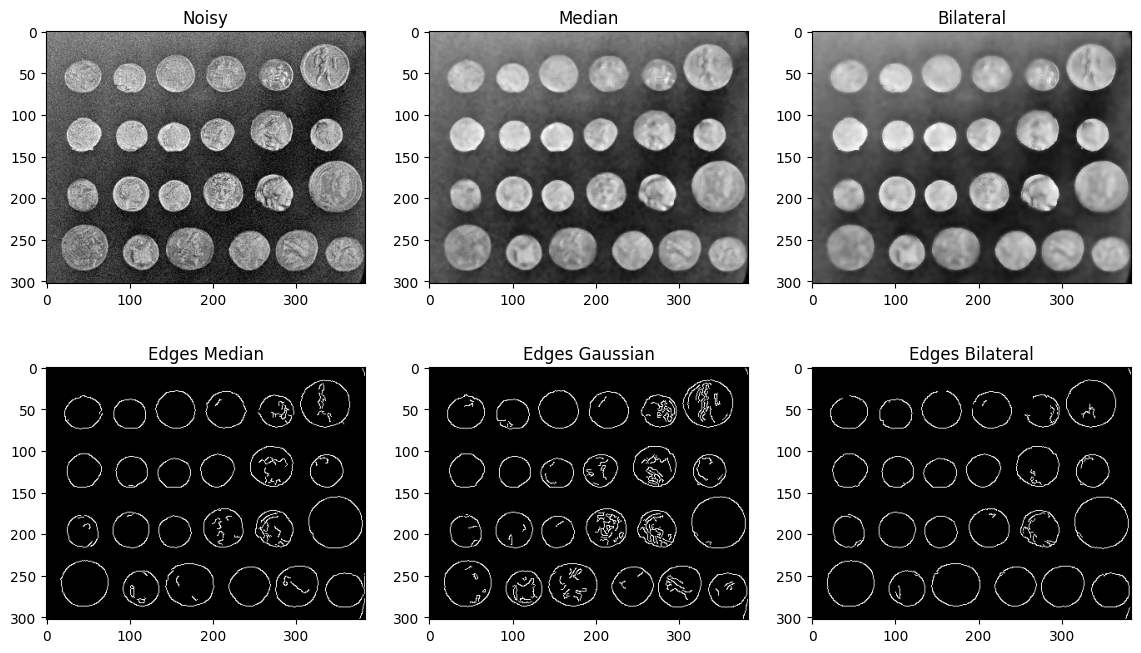

In [ ]:
# LATIHAN 4

from skimage import data

coins = data.coins()

# Tambahkan noise
noise = coins + np.random.normal(0, 15, coins.shape)
noise = np.clip(noise, 0, 255).astype(np.uint8)

# 1) Median
med = cv2.medianBlur(noise, 5)

# 2) Gaussian
ga = cv2.GaussianBlur(noise, (5,5), 1)

# 3) Bilateral
bil = cv2.bilateralFilter(noise, 9, 75, 75)

# 4) Canny
edges_orig = cv2.Canny(noise, 100, 200)
edges_med  = cv2.Canny(med, 100, 200)
edges_ga   = cv2.Canny(ga, 100, 200)
edges_bil  = cv2.Canny(bil, 100, 200)

plt.figure(figsize=(14,8))
plt.subplot(2,3,1); plt.imshow(noise, cmap='gray'); plt.title("Noisy")
plt.subplot(2,3,2); plt.imshow(med, cmap='gray'); plt.title("Median")
plt.subplot(2,3,3); plt.imshow(bil, cmap='gray'); plt.title("Bilateral")

plt.subplot(2,3,4); plt.imshow(edges_med, cmap='gray'); plt.title("Edges Median")
plt.subplot(2,3,5); plt.imshow(edges_ga, cmap='gray'); plt.title("Edges Gaussian")
plt.subplot(2,3,6); plt.imshow(edges_bil, cmap='gray'); plt.title("Edges Bilateral")
plt.show()